In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes_polar_full_overlap,add_disinfo_nodes,state_to_graph, er_opinion_graph
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing,in_and_out_degree_sum,cross_type_degree
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
n, k = 10000, 150
p_er = k / (n - 1)

In [3]:
ws_Scenarie5 = ws_opinion_graph(n,k,seed = 11)
ws_Scenarie5matrix = create_matrix_rep(ws_Scenarie5)
ws_MedierScenarie5 = add_media_nodes_polar_full_overlap(ws_Scenarie5matrix,1,seed = 11)


er_Scenarie5 = er_opinion_graph(n,p_er,seed = 11)
er_Scenarie5matrix = create_matrix_rep(er_Scenarie5)
er_MedierScenarie5 = add_media_nodes_polar_full_overlap(er_Scenarie5matrix,1,seed = 11)

In [4]:
ws_MedierScenarie5.opinions, ws_MedierScenarie5_sim_results,ws_Scenarie5_startcond,ws_Scenarie5_endcond= simpel_simulering(ws_MedierScenarie5,200)

er_MedierScenarie5.opinions, er_MedierScenarie5_sim_results,er_Scenarie5_startcond,er_Scenarie5_endcond= simpel_simulering(er_MedierScenarie5,200)


Simulating: 100%|██████████| 200/200 [00:13<00:00, 15.35it/s]


In [5]:
# ws
ws_maskhumanScenarie5 = ws_MedierScenarie5.type == "Human"
ws_Hoved_average_opinionresult, ws_Hoved_average_distance_to_the_mean_result = data_processing(ws_MedierScenarie5_sim_results,ws_maskhumanScenarie5)


# er
er_maskhumanScenarie5 = er_MedierScenarie5.type == "Human"
er_Hoved_average_opinionresult, er_Hoved_average_distance_to_the_mean_result = data_processing(er_MedierScenarie5_sim_results,er_maskhumanScenarie5)

In [6]:
ws_binsScenarie5 = np.histogram_bin_edges(np.concatenate([ws_Scenarie5_startcond[ws_maskhumanScenarie5], ws_Scenarie5_endcond[ws_maskhumanScenarie5]]), bins=100)
er_binsScenarie5 = np.histogram_bin_edges(np.concatenate([er_Scenarie5_startcond[er_maskhumanScenarie5], er_Scenarie5_endcond[er_maskhumanScenarie5]]), bins=100)


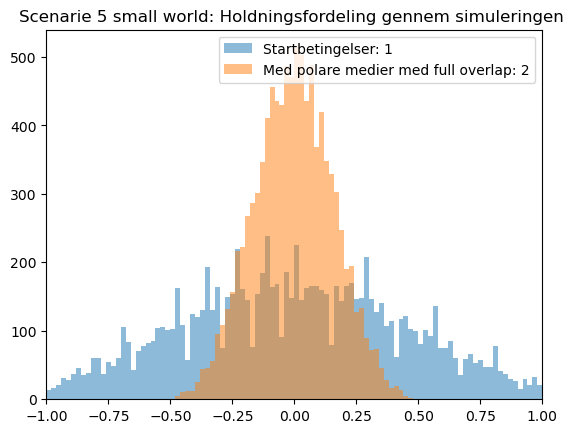

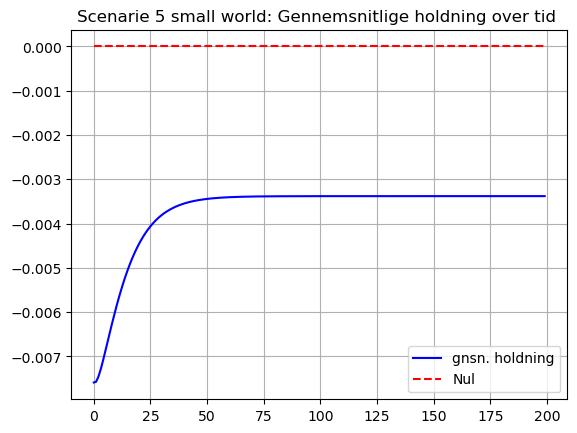

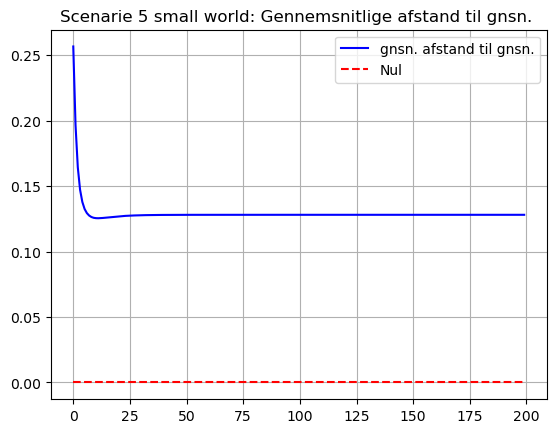

In [7]:
plt.figure()
plt.hist(ws_Scenarie5_startcond[ws_maskhumanScenarie5], bins=ws_binsScenarie5, alpha=0.5, label='Startbetingelser: 1')
plt.hist(ws_Scenarie5_endcond[ws_maskhumanScenarie5], bins=ws_binsScenarie5, alpha=0.5, label='Med polare medier med full overlap: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 5 small world: Holdningsfordeling gennem simuleringen ')
plt.show()


plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),ws_Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),np.zeros(len(ws_Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 5 small world: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),ws_Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),np.zeros(len(ws_Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 5 small world: Gennemsnitlige afstand til gnsn. ')
plt.show()

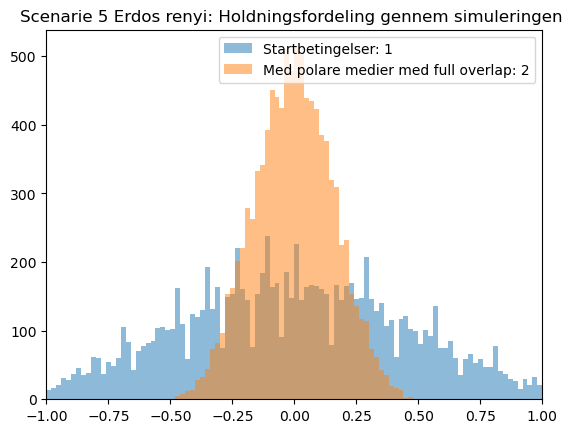

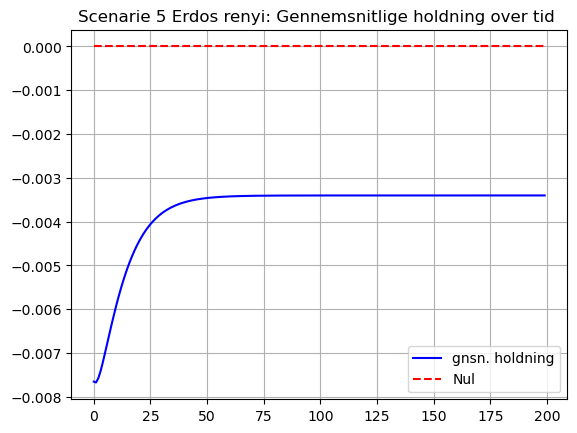

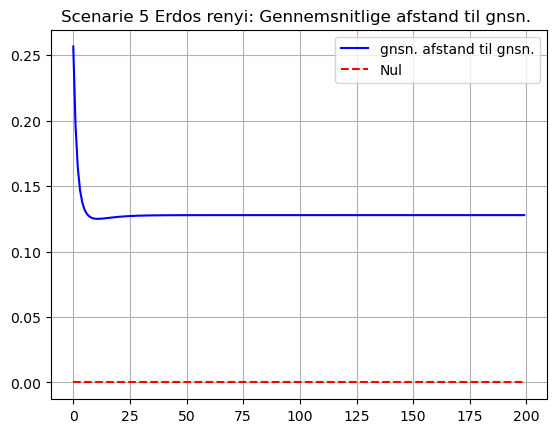

In [8]:
plt.figure()
plt.hist(er_Scenarie5_startcond[er_maskhumanScenarie5], bins=er_binsScenarie5, alpha=0.5, label='Startbetingelser: 1')
plt.hist(er_Scenarie5_endcond[er_maskhumanScenarie5], bins=er_binsScenarie5, alpha=0.5, label='Med polare medier med full overlap: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 5 Erdos renyi: Holdningsfordeling gennem simuleringen ')
plt.show()


plt.figure()
plt.plot(np.arange(len(er_Hoved_average_opinionresult)),er_Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(er_Hoved_average_opinionresult)),np.zeros(len(er_Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 5 Erdos renyi: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_result)),er_Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_result)),np.zeros(len(er_Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 5 Erdos renyi: Gennemsnitlige afstand til gnsn. ')
plt.show()